In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
from collections import defaultdict

In [5]:
df = pd.read_csv("data_prompts/man-annotated-train-high-risk.csv")
#print a table of results with the counts of "annotation" values per "high_risk_label" value
counts = (
    df.groupby("high_risk_label")["annotation"]
    .value_counts()
    .unstack(fill_value=0)
)
total_row = counts[["Analytical", "Factual"]].sum().rename("Total")
counts = pd.concat([counts, total_row.to_frame().T])
latex_table = counts.to_latex()
print(latex_table)


\begin{tabular}{lrr}
\toprule
annotation & Analytical & Factual \\
\midrule
Economic and Financial & 615 & 273 \\
Health & 397 & 363 \\
Judicial and Legal & 95 & 152 \\
Moral Values and Religion & 422 & 117 \\
Other & 74 & 38 \\
Politics & 98 & 99 \\
Security & 214 & 120 \\
Total & 1915 & 1162 \\
\bottomrule
\end{tabular}



In [2]:
df = pd.read_csv("data_prompts/infoseek-llm.csv")
id2label = {row["prompt_id"]: row["annotation"] for _, row in df.iterrows()}
id2topic = {row["prompt_id"]: row["label"] for _, row in df.iterrows()}
df

,Unnamed: 0,prompt_id,label,content,annotation
0,0,193296_ShareGPT,Security,"the browser is not trusting , probably because...",Procedural
1,1,6354_elisa,Moral Values and Religion,Why do zodiac signs seem accurate? By that I m...,Subjective
2,2,3305_elisa,Economic and Financial,Approximately what % of $20 bets would you nee...,Factual
3,3,4071_elisa,Economic and Financial,How many covers would i need to serve to turn ...,Analytical
4,4,323453_lmsys-chat-1m,Economic and Financial,suggest instagram theme page ideas where i can...,Analytical
...,...,...,...,...,...
3118,3118,217818_WildChat,Economic and Financial,How can we leverage AI in private banking?,Analytical
3119,3119,90244_WildChat,Economic and Financial,The best and low fees payment processor for a ...,Analytical
3120,3120,124942_WildChat,Economic and Financial,Find the amount due on a J&T Sdn Bhd invoice f...,Analytical
3121,3121,192074_WildChat,Economic and Financial,"If US$1=100₽, is that bad for the Russian econ...",Analytical


In [3]:
files = glob.glob("data/responses_with_search/forced_search_tool*.csv")
search_df = pd.DataFrame()
for file in files:
    search_df = pd.concat([search_df, pd.read_csv(file)], ignore_index=True)
print(search_df)
search_df["annotation"] = search_df["prompt_id"].map(id2label)
search_df["topic"] = search_df["prompt_id"].map(id2topic)
search_df

                 prompt_id                                           response  \
0               4784_elisa  Here’s a structured, comprehensive guide to so...   
1          282522_WildChat  Here’s a comprehensive overview of how free VP...   
2           73179_WildChat  Here’s a comprehensive, up-to-date review of A...   
3          142541_WildChat  Could you clarify what you mean by “obetive ab...   
4     318569_lmsys-chat-1m  Here’s what constitutes **black powder**, also...   
...                    ...                                                ...   
2329       217818_WildChat  Here’s a detailed, structured overview of how ...   
2330        90244_WildChat  Here’s a detailed and up-to-date guide to sele...   
2331       124942_WildChat  Here’s how to determine the amount due on the ...   
2332       192074_WildChat  Here’s an updated, detailed analysis of whethe...   
2333       156215_WildChat  Here’s a polished “Fiverr Gig FAQ” section add...   

                           

,prompt_id,response,links,annotation,topic
0,4784_elisa,"Here’s a structured, comprehensive guide to so...",https://timesofindia.indiatimes.com/life-style...,Analytical,Security
1,282522_WildChat,Here’s a comprehensive overview of how free VP...,https://www.ctol.digital/news/free-vpns-google...,Analytical,Security
2,73179_WildChat,"Here’s a comprehensive, up-to-date review of A...",https://www.anydesk.com/en/performance|||https...,Factual,Security
3,142541_WildChat,Could you clarify what you mean by “obetive ab...,NaN,Analytical,Security
4,318569_lmsys-chat-1m,"Here’s what constitutes **black powder**, also...",https://www.britannica.com/technology/gunpowde...,Factual,Security
...,...,...,...,...,...
2329,217818_WildChat,"Here’s a detailed, structured overview of how ...",https://www.sc.com/en/news/private-bank/ai-and...,Analytical,Economic and Financial
2330,90244_WildChat,Here’s a detailed and up-to-date guide to sele...,https://madjar.io/landing|||https://websuccess...,Analytical,Economic and Financial
2331,124942_WildChat,Here’s how to determine the amount due on the ...,https://www.coursehero.com/file/p5ll8h6/Receip...,Analytical,Economic and Financial
2332,192074_WildChat,"Here’s an updated, detailed analysis of whethe...",https://en.iz.ru/en/1933096/2025-08-07/experts...,Analytical,Economic and Financial


In [4]:
def fetch_domain_in_links(links):
    """ Fetch the domain from a link to get after https:// and before the first / """
    if pd.isna(links):
        return []
    links = links.split("|||")
    domains = []
    for link in links:
        if link.startswith("http://"):
            link = link[len("http://"):]
        elif link.startswith("https://"):
            link = link[len("https://"):]
        domain = link.split("/")[0]
        domains.append(domain)
    return domains

In [5]:
files = glob.glob("data/responses_with_search/auto_search_tool*.csv")
autosearch_df = pd.DataFrame()
for file in files:
    autosearch_df = pd.concat([autosearch_df, pd.read_csv(file)], ignore_index=True)
autosearch_df["annotation"] = autosearch_df["prompt_id"].map(id2label)
autosearch_df["topic"] = autosearch_df["prompt_id"].map(id2topic)
autosearch_df



,prompt_id,response,links,annotation,topic
0,4586_elisa,Accusations of racism in the music industry ha...,NaN,Factual,Moral Values and Religion
1,3873_elisa,Wanting to deepen your boyfriend's attraction ...,NaN,Subjective,Moral Values and Religion
2,2452_elisa,Great question! This touches on both archaeolo...,NaN,Analytical,Moral Values and Religion
3,34926_ShareGPT,Certainly! Here are **five of the most influen...,NaN,Subjective,Moral Values and Religion
4,210690_ShareGPT,Certainly! The **regulative principle of worsh...,NaN,Analytical,Moral Values and Religion
...,...,...,...,...,...
3118,234398_WildChat,Having **reliable leaders** is critically impo...,NaN,Analytical,Politics
3119,344153_WildChat,Absolutely! Power transitions in democratic co...,NaN,Analytical,Politics
3120,387959_WildChat,"In George Orwell’s novel **""1984,""** the **Bro...",NaN,Factual,Politics
3121,436631_WildChat,Mastering politics requires a blend of hard an...,NaN,Subjective,Politics


In [6]:
def fetch_features_in_links(df):
    df["annotation"] = df["prompt_id"].map(id2label)
    df["domains"] = df["links"].apply(fetch_domain_in_links)
    df["n_domains"] = df["domains"].apply(lambda x: len(x))
    return df

In [7]:
def plot_n_domains_by_category(df, category_col, title):
    # plot the distribution of n_domains for each annotation
    df.boxplot(column="n_domains", by=category_col, grid=False)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.suptitle("")
    plt.xlabel(category_col)
    plt.ylabel("Number of domains")
    plt.show()

topic
Economic and Financial       2.682112
Health                       0.716184
Judicial and Legal           2.071713
Moral Values and Religion    0.132554
Politics                     2.295238
Security                     1.508906
Name: n_domains, dtype: float64
topic
Economic and Financial       928
Health                       828
Moral Values and Religion    513
Security                     393
Judicial and Legal           251
Politics                     210
Name: count, dtype: int64


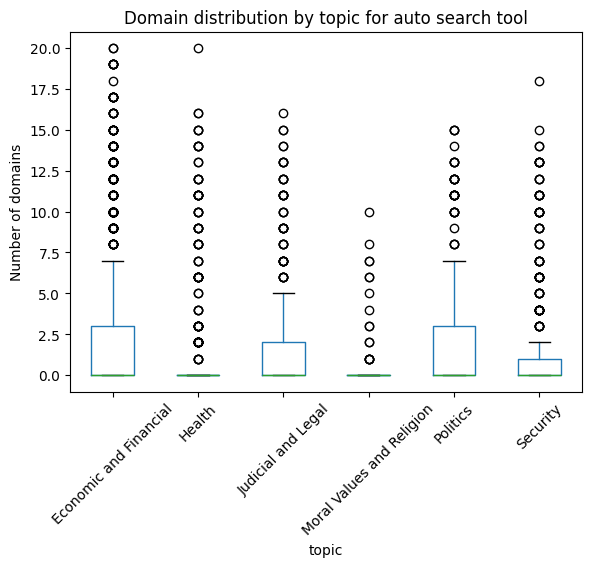

In [8]:
autosearch_df = fetch_features_in_links(autosearch_df)
print(autosearch_df.groupby("topic")["n_domains"].mean())  
print(autosearch_df.topic.value_counts())
plot_n_domains_by_category(autosearch_df, "topic", "Domain distribution by topic for auto search tool")

annotation
Analytical    1.446228
Factual       1.916382
Predictive    4.845070
Procedural    1.061224
Subjective    0.324074
Name: n_domains, dtype: float64
annotation
Analytical    1246
Factual       1172
Subjective     432
Procedural     196
Predictive      71
Name: count, dtype: int64


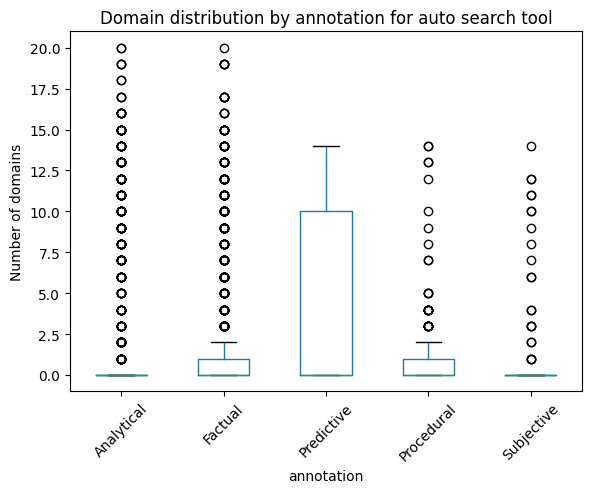

In [10]:
autosearch_df = fetch_features_in_links(autosearch_df)
print(autosearch_df.groupby("annotation")["n_domains"].mean())  
print(autosearch_df.annotation.value_counts())
plot_n_domains_by_category(autosearch_df, "annotation", "Domain distribution by annotation for auto search tool")

topic
Economic and Financial        9.536638
Health                       11.140000
Judicial and Legal            8.400000
Moral Values and Religion     7.859649
Politics                      8.330000
Security                      8.581788
Name: n_domains, dtype: float64
topic
Economic and Financial       928
Security                     593
Moral Values and Religion    513
Health                       100
Judicial and Legal           100
Politics                     100
Name: count, dtype: int64


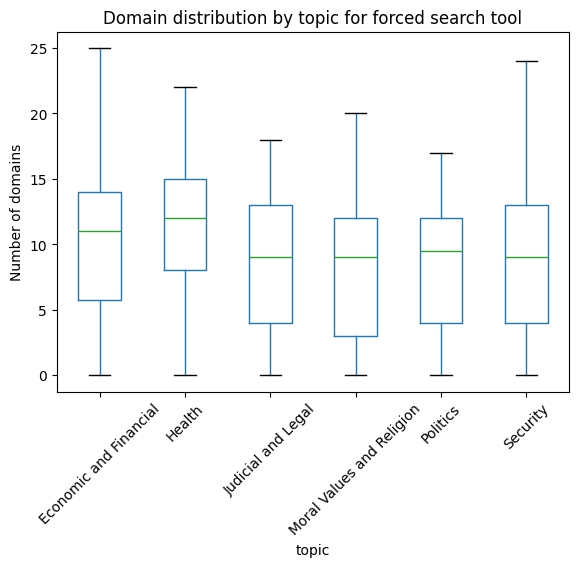

In [11]:
search_df = fetch_features_in_links(search_df)
print(search_df.groupby("topic")["n_domains"].mean())  
print(search_df.topic.value_counts())
plot_n_domains_by_category(search_df, "topic", "Domain distribution by topic for forced search tool")

annotation
Analytical    9.670526
Factual       8.784657
Predictive    9.733333
Procedural    7.791262
Subjective    7.687500
Name: n_domains, dtype: float64
annotation
Analytical    950
Factual       743
Subjective    368
Procedural    206
Predictive     60
Name: count, dtype: int64


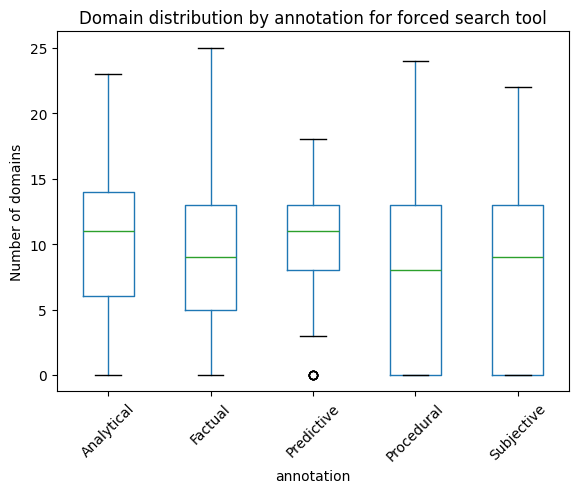

In [12]:
search_df = fetch_features_in_links(search_df)
print(search_df.groupby("annotation")["n_domains"].mean())  
print(search_df.annotation.value_counts())
plot_n_domains_by_category(search_df, "annotation", "Domain distribution by annotation for forced search tool")

## Analysis Domains

In [12]:
all_domains = set(autosearch_df["domains"].explode().unique()) | set(search_df["domains"].explode().unique())
print(f"Number of unique domains in autosearch: {len(set(autosearch_df['domains'].explode().unique()))}")
print(f"Number of unique domains in search: {len(set(search_df['domains'].explode().unique()))}")
print(f"Number of unique domains in both: {len(all_domains)}")

Number of unique domains in autosearch: 1222
Number of unique domains in search: 4622
Number of unique domains in both: 5336


In [13]:
from collections import Counter
domains = [i for i in search_df["domains"].explode() if str(i) != "nan"]
count_domains = Counter(domains)
print("Top 20 domains in autosearch:")
for domain, count in count_domains.most_common(20):
    print(f"{domain}: {count}")


Top 20 domains in autosearch:
en.wikipedia.org: 1963
www.reddit.com: 330
www.britannica.com: 228
www.forbes.com: 176
arxiv.org: 173
www.theguardian.com: 164
www.investopedia.com: 163
apnews.com: 115
www.businessinsider.com: 79
legalclarity.org: 75
timesofindia.indiatimes.com: 70
pmc.ncbi.nlm.nih.gov: 70
www.linkedin.com: 68
nypost.com: 62
www.washingtonpost.com: 60
time.com: 57
www.kiplinger.com: 56
www.healthline.com: 56
learn.microsoft.com: 54
www.mdpi.com: 53


In [20]:
# with open("data/responses_with_search/unique_domains_search.txt", "w") as f:
#     for domain in count_domains.keys():
#         if count_domains[domain] > 1:  # Only write domains that appear more than once
#             f.write(domain + "\n")
# f.close()

In [14]:
with open("data/responses_with_search/unique_domains_autosearch.txt", "r") as f:
    unique_domains = f.read().splitlines()
auto_search_domain2category = {}
for domain in unique_domains:
    domain = domain.split("\t")
    auto_search_domain2category[domain[0]] = domain[-1]
print(f"Number of unique domains read from file: {len(unique_domains)}")

Number of unique domains read from file: 132


In [15]:
with open("data/responses_with_search/unique_domains_search.txt", "r") as f:
    unique_domains = f.read().splitlines()
search_domain2category = {}
for domain in unique_domains:
    domain = domain.split("\t")
    search_domain2category[domain[0]] = domain[-1]
print(f"Number of unique domains read from file: {len(unique_domains)}")

Number of unique domains read from file: 1101


In [18]:
def map_domain_to_category(map_dicdomain, domain):
    if domain in map_dicdomain:
        return map_dicdomain[domain]
    else:
        return "unknown"


autosearch_df["domain_categories"] = autosearch_df["domains"].apply(lambda domains: [map_domain_to_category(auto_search_domain2category, domain) for domain in domains])
categories = autosearch_df["domain_categories"].explode().unique().tolist()
search_df["domain_categories"] = search_df["domains"].apply(lambda domains: [map_domain_to_category(search_domain2category, domain) for domain in domains])

def categories_to_binary_features(df, categories):
    for idx, row in df.iterrows():
        dic = {k: 0 for k in categories}
        for cat in row["domain_categories"]:
            dic[cat] += 1
        for cat in categories:
            df.loc[idx, f"{cat}"] = dic[cat]  # Use .loc to assign to specific row
    return df

autosearch_df = categories_to_binary_features(autosearch_df, categories)
search_df = categories_to_binary_features(search_df, categories)
autosearch_df[-10:]

# print(f"Unique domain categories in autosearch: {categories}")

,prompt_id,response,links,annotation,topic,domains,n_domains,domain_categories,nan,Science,News Outlets,unknown,Archives & Reference,Corporate / Commercial,Blogs & Online Commentary,Advocacy / NGO / Civil Society,Government
1872,2388_elisa,You asked: **How many Americans have at least ...,https://www.investopedia.com/us-added-over-100...,Factual,Economic and Financial,"[www.investopedia.com, www.forbes.com, www.hen...",5,"[Archives & Reference, News Outlets, unknown, ...",0.0,0.0,1.0,3.0,1.0,0.0,0.0,0.0,0.0
1873,5626_elisa,Here is the current exchange rate for the Brit...,https://gbp.currencyrate.today/usd|||https://w...,Factual,Economic and Financial,"[gbp.currencyrate.today, www.exchange-rates.or...",3,"[unknown, Archives & Reference, News Outlets]",0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
1874,2394_elisa,"Great question! When searching for jobs, the i...",NaN,Analytical,Economic and Financial,[],0,[],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1875,4459_elisa,Absolutely! I’d love to help you plan a budget...,NaN,Analytical,Economic and Financial,[],0,[],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1876,3605_elisa,Setting up an **automated trading bot for scal...,https://developer.betfair.com/|||https://docs....,Procedural,Economic and Financial,"[developer.betfair.com, docs.developer.betfair...",10,"[unknown, unknown, unknown, unknown, unknown, ...",0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0
1877,285747_WildChat,When you do not know the name of the boss or h...,NaN,Analytical,Economic and Financial,[],0,[],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1878,1980_elisa,Implementing a **tourism levy** (sometimes cal...,NaN,Analytical,Economic and Financial,[],0,[],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1879,6004_elisa,**Mutually exchanging social housing** (also c...,https://www.homeswapper.co.uk/|||https://www.h...,Procedural,Economic and Financial,"[www.homeswapper.co.uk, www.houseexchange.org....",5,"[unknown, unknown, unknown, unknown, unknown]",0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
1880,398_elisa,Here’s a detailed and up-to-date breakdown of ...,https://www.tomshardware.com/reviews/best-pc-b...,Analytical,Economic and Financial,"[www.tomshardware.com, www.tomshardware.com, w...",12,"[unknown, unknown, unknown, unknown, unknown, ...",0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0
1881,1257_elisa,The statement is **false**.\n\n**Explanation:*...,NaN,Analytical,Economic and Financial,[],0,[],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


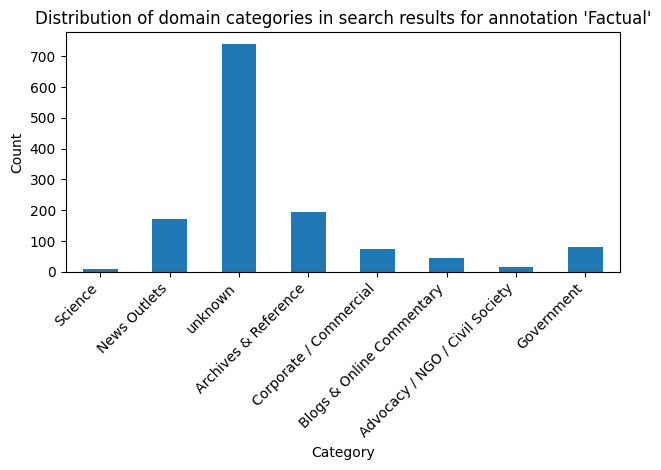

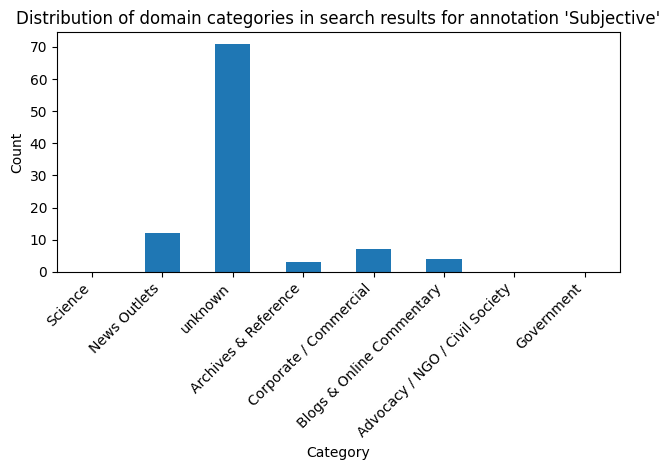

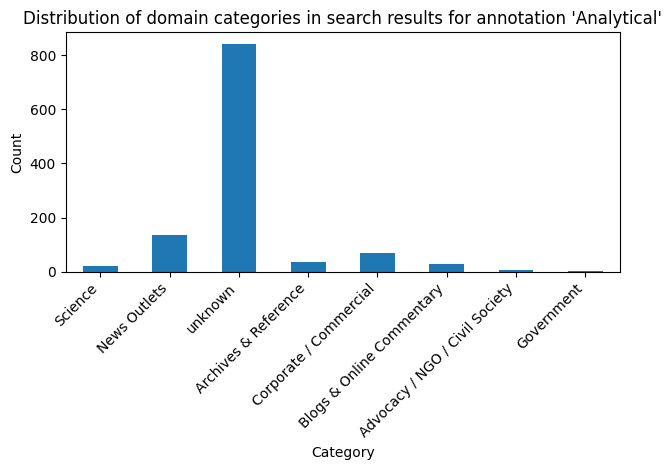

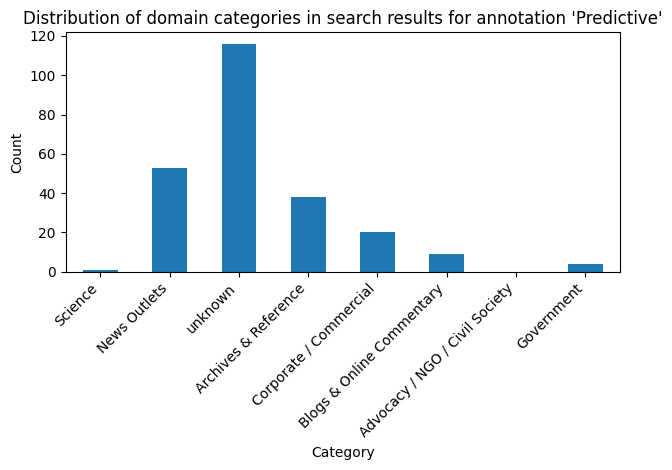

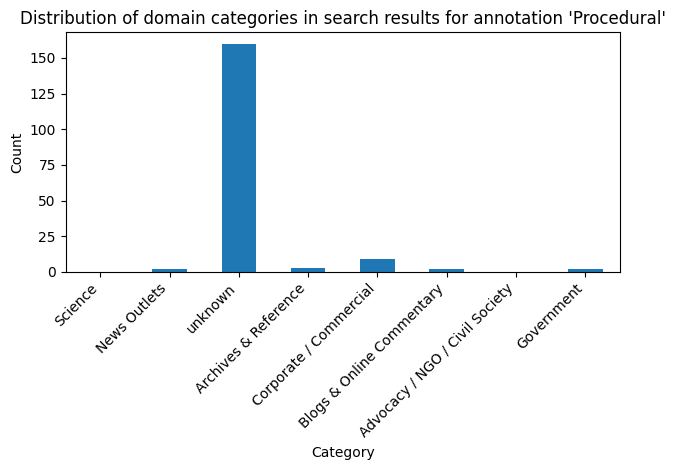

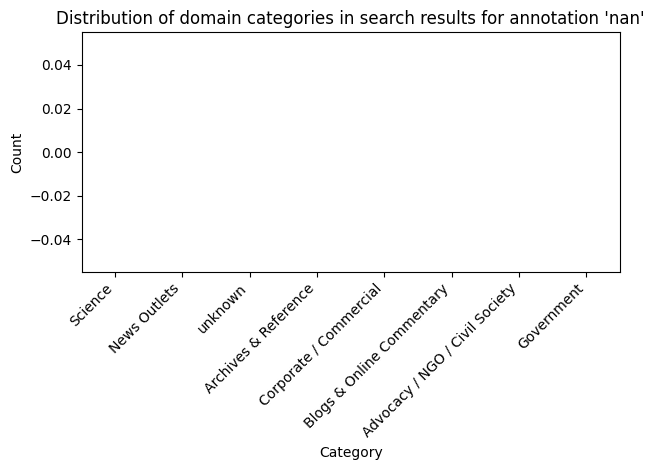

In [19]:
# Plot all categories together
def plot_all_categories(df, categories, annotation=None):
    category_counts = {}
    for cat in categories:
        if str(cat) != "nan":
            category_counts[cat] = df[cat].sum()
    
    pd.Series(category_counts).plot(kind="bar")
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Distribution of domain categories in search results for annotation '{annotation}'")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

for annotation in autosearch_df["annotation"].unique():
     subset_df = autosearch_df[autosearch_df["annotation"] == annotation]
     plot_all_categories(subset_df, categories, annotation=annotation)

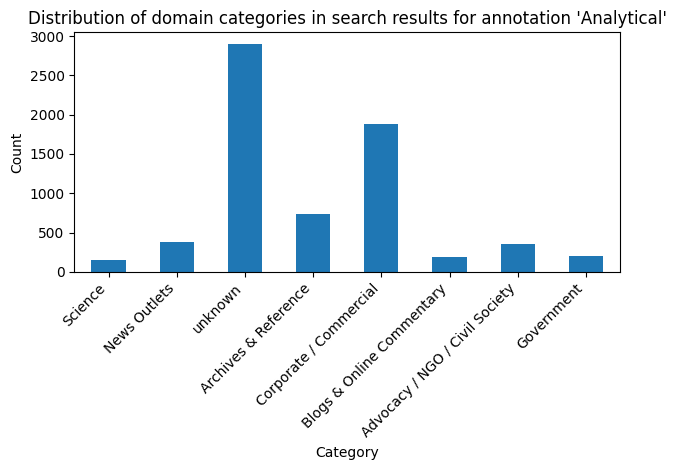

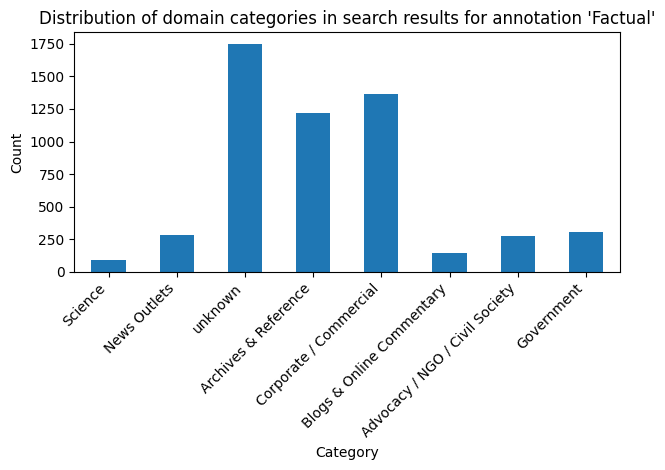

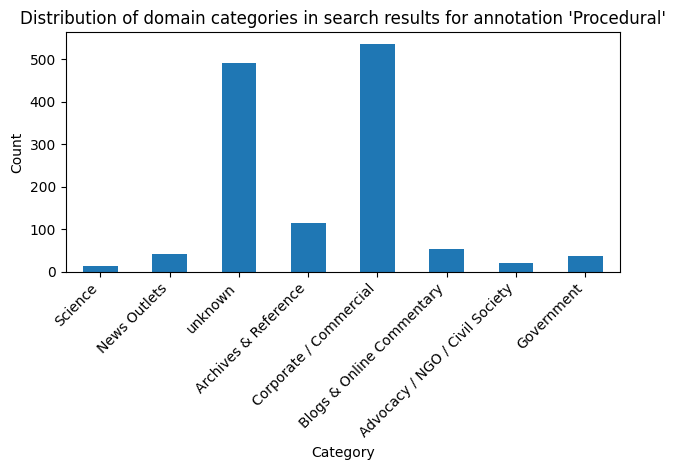

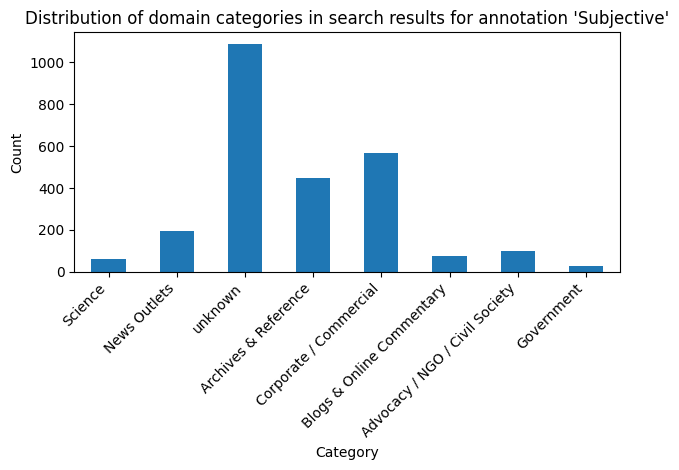

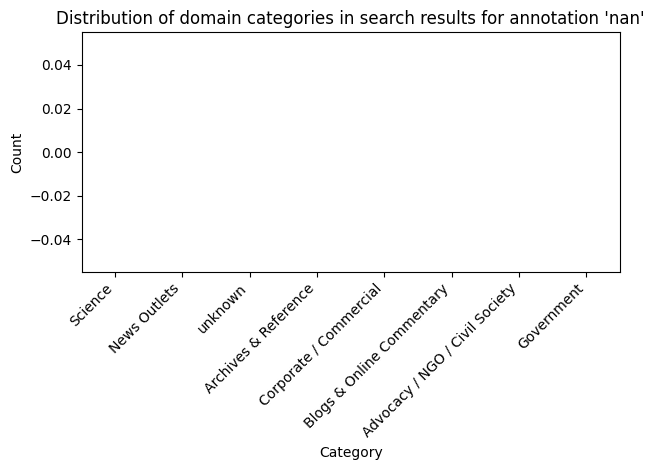

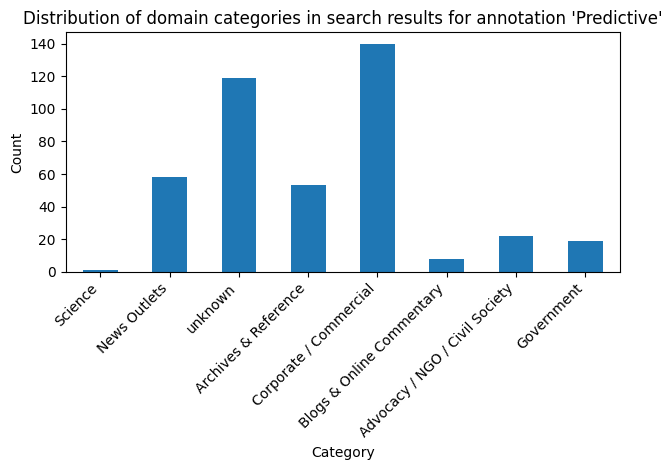

In [21]:
for annotation in search_df["annotation"].unique():
     subset_df = search_df[search_df["annotation"] == annotation]
     plot_all_categories(subset_df, categories, annotation=annotation)

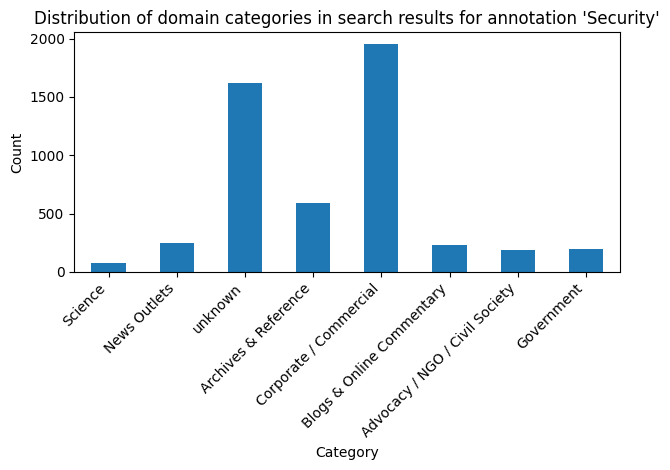

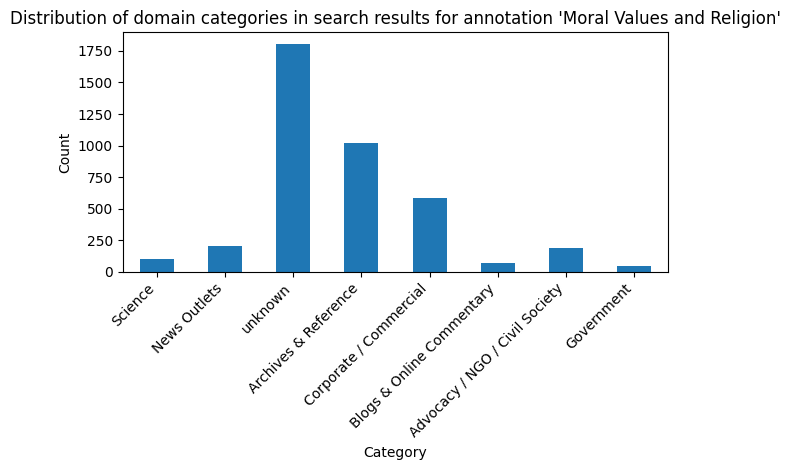

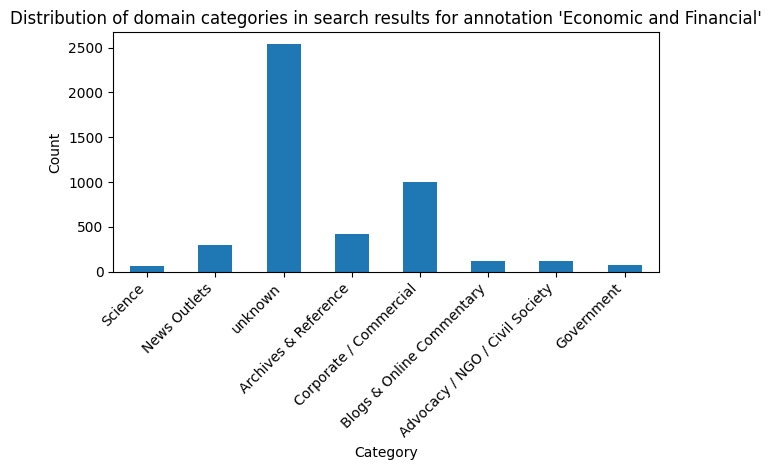

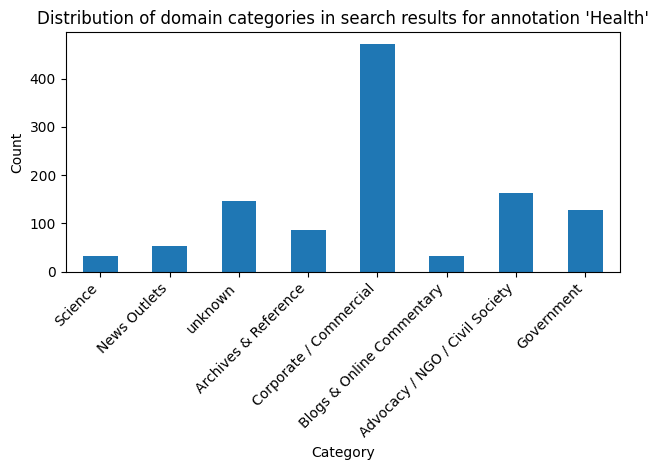

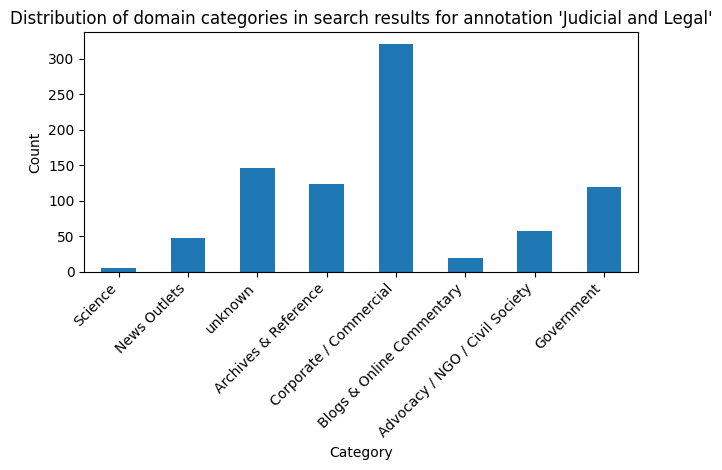

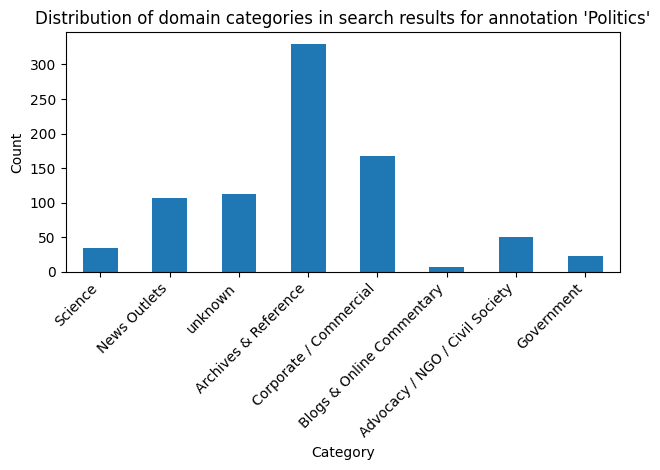

In [24]:
for annotation in search_df["topic"].unique():
     subset_df = search_df[search_df["topic"] == annotation]
     plot_all_categories(subset_df, categories, annotation=annotation)

In [27]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Example: df is your dataframe
# Ensure categorical variables are treated correctly
autosearch_df["annotation"] = autosearch_df["annotation"].astype("category")
autosearch_df["topic"] = autosearch_df["topic"].astype("category")

# Fit Negative Binomial model
model = smf.glm(
    formula="n_domains ~ annotation + topic",
    data=autosearch_df,
    family=sm.families.NegativeBinomial()
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              n_domains   No. Observations:                 1877
Model:                            GLM   Df Residuals:                     1867
Model Family:        NegativeBinomial   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2770.8
Date:                Mon, 02 Mar 2026   Deviance:                       3294.9
Time:                        16:08:13   Pearson chi2:                 7.03e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.3980
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

/home/ceron/miniconda3/envs/llm_info/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [28]:
import numpy as np

np.exp(model.params)

Intercept                             2.409974
annotation[T.Factual]                 1.449632
annotation[T.Predictive]              2.624085
annotation[T.Procedural]              0.648006
annotation[T.Subjective]              0.424250
topic[T.Health]                       0.239679
topic[T.Judicial and Legal]           0.657862
topic[T.Moral Values and Religion]    0.065654
topic[T.Politics]                     0.694922
topic[T.Security]                     0.606924
dtype: float64

In [42]:
full_model = smf.glm(
    "n_domains ~ annotation + topic",
    data=autosearch_df,
    family=sm.families.NegativeBinomial()
).fit()

no_query = smf.glm(
    "n_domains ~ topic",
    data=autosearch_df,
    family=sm.families.NegativeBinomial()
).fit()

no_topic = smf.glm(
    "n_domains ~ annotation",
    data=autosearch_df,
    family=sm.families.NegativeBinomial()
).fit()

/home/ceron/miniconda3/envs/llm_info/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/home/ceron/miniconda3/envs/llm_info/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/home/ceron/miniconda3/envs/llm_info/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [40]:
pseudo_r2_full = 1 - (full_model.deviance / full_model.null_deviance)
pseudo_r2_no_topic = 1 - (no_query.deviance / no_query.null_deviance)
pseudo_r2_no_annotation = 1 - (no_topic.deviance / no_topic.null_deviance)

print(f"Pseudo R-squared for full model: {pseudo_r2_full:.4f}")
print(f"Pseudo R-squared for model without annotation: {pseudo_r2_no_annotation:.4f}")
print(f"Pseudo R-squared for model without topic: {pseudo_r2_no_topic:.4f}")

Pseudo R-squared for full model: 0.2243
Pseudo R-squared for model without annotation: 0.0928
Pseudo R-squared for model without topic: 0.1925
